In [5]:
# ============================================================
# CELDA 0 — Setup, funciones compartidas y conexion unica
# ============================================================
# Todas las pruebas de este notebook (captura simple, barrido de potencia,
# barrido de fase) comparten UNA SOLA conexion (sock), abierta aca. No se
# vuelve a abrir ni cerrar en las celdas siguientes -- solo se cierra al
# final del notebook (ultima celda).
#
# TX: dds_compiler de frecuencia fija a 10.7 MHz + 9.6 kHz, conectado
# directo al DAC (sin PS, sin FIFO, sin CMD_TX_*). El tono ya esta
# saliendo por el DAC de forma continua en cuanto el bitstream corre; este
# notebook no lo controla, solo recibe.

import socket
import struct
import time
import numpy as np
import matplotlib.pyplot as plt

HOST = '10.36.157.50'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05

FS       = 125e6
fs_out   = FS / 651              # tasa de salida CIC+FIR (un canal I o Q)
f_lo_hz  = 10.7e6                # LO del receptor (frecuencia base)
f_offset = 9.6e3                 # offset del tono TX fijo respecto al LO base
f_tono_tx = f_lo_hz + f_offset    # frecuencia fija del tono TX (autonomo)

f_min_khz = -20.0
f_max_khz =  20.0

PINC = round(f_lo_hz / FS * (1 << 30))
CFG_VAL_RESET = (PINC << 1) | 0
CFG_VAL_RUN   = (PINC << 1) | 1

print(f"PINC = {PINC}")
print(f"fs_out = {fs_out:.0f} sps")
print(f"Muestras/simbolo a 9600 bps: {fs_out/9600:.2f}")
print(f"Tono TX fijo: {f_tono_tx/1e6:.6f} MHz (offset +{f_offset/1e3:.1f} kHz sobre {f_lo_hz/1e6:.1f} MHz)")


def send_cmd(sock, cmd, payload):
    """Envia un comando (1 byte) + payload (4 bytes)."""
    sock.sendall(struct.pack('B', cmd))
    sock.sendall(struct.pack('I', payload))


def read_ack(sock):
    """Lee el byte de confirmacion del servidor."""
    data = sock.recv(1)
    return data[0] == 0x01


def set_lo(sock, f_lo_hz, con_reset=False):
    """Configura el PINC del LO (osc_0, receptor).
    con_reset=False (default): solo cambia el PINC en caliente, sin tocar
    el bit de reset -- usar esto DENTRO de un barrido, para no perturbar
    la continuidad de fase entre puntos sucesivos.
    con_reset=True: hace un pulso reset->run -- usar esto UNA sola vez,
    al principio de cada prueba, para arrancar desde un estado conocido."""
    PINC = round(f_lo_hz / FS * (1 << 30))
    if con_reset:
        send_cmd(sock, CMD_SET_CFG, (PINC << 1) | 0); read_ack(sock)
    send_cmd(sock, CMD_SET_CFG, (PINC << 1) | 1); read_ack(sock)
    return PINC


def resetear_fifo(sock):
    """Resetea el FIFO de captura. Se llama UNA sola vez antes de un
    barrido, no en cada punto -- resetear en cada punto reinicia el
    instante de arranque de la captura de forma independiente cada vez,
    y como el dds_compiler de TX es un oscilador libre que nunca se
    sincroniza con ese reset, la fase absoluta medida en cada punto queda
    aleatoria (verificado empiricamente). Sin resetear entre puntos, las
    capturas sucesivas leen el stream continuo, preservando la fase real."""
    send_cmd(sock, CMD_SET_FIFO, 0); read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1); read_ack(sock)


def capturar_iq(sock, n_samples):
    """Lee n_samples muestras complejas (I, Q) del ADC. NO resetea el
    FIFO -- ver resetear_fifo() para eso."""
    n_words = n_samples * 2
    send_cmd(sock, CMD_READ_ADC, n_words)
    raw = b''
    total = n_words * 4
    while len(raw) < total:
        raw += sock.recv(total - len(raw))
    words = struct.unpack(f'{n_words}i', raw)
    I_bb = np.array(words[0::2], dtype=float)
    Q_bb = np.array(words[1::2], dtype=float)
    return I_bb, Q_bb


def medir_potencia(iq):
    """Potencia total, sin ventana ni FFT: mean(|I+jQ|^2)."""
    return 10 * np.log10(np.mean(np.abs(iq)**2) + 1e-20)


def medir_fase_senal(iq, f_bb_esperada, fs, ventana_hz=5e3):
    """Fase de la señal en el bin de FFT mas cercano a la frecuencia banda
    base esperada (busca el pico de magnitud dentro de una ventana
    alrededor de esa frecuencia, para no engancharse con ruido lejano)."""
    n = len(iq)
    S = np.fft.fftshift(np.fft.fft(iq))
    freqs = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    mask = np.abs(freqs - f_bb_esperada) <= ventana_hz
    if not mask.any():
        return np.nan, np.nan
    idx_local = np.argmax(np.abs(S[mask]))
    idx_global = np.where(mask)[0][idx_local]
    return np.angle(S[idx_global], deg=True), freqs[idx_global]


# --- conexion UNICA para todo el notebook ---
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.connect((HOST, PORT))
print("Conectado.")

set_lo(sock, f_lo_hz, con_reset=True)
resetear_fifo(sock)
print(f"LO inicial en {f_lo_hz/1e6:.4f} MHz, FIFO reseteado.")


PINC = 91912300
fs_out = 192012 sps
Muestras/simbolo a 9600 bps: 20.00
Tono TX fijo: 10.709600 MHz (offset +9.6 kHz sobre 10.7 MHz)
Conectado.
LO inicial en 10.7000 MHz, FIFO reseteado.


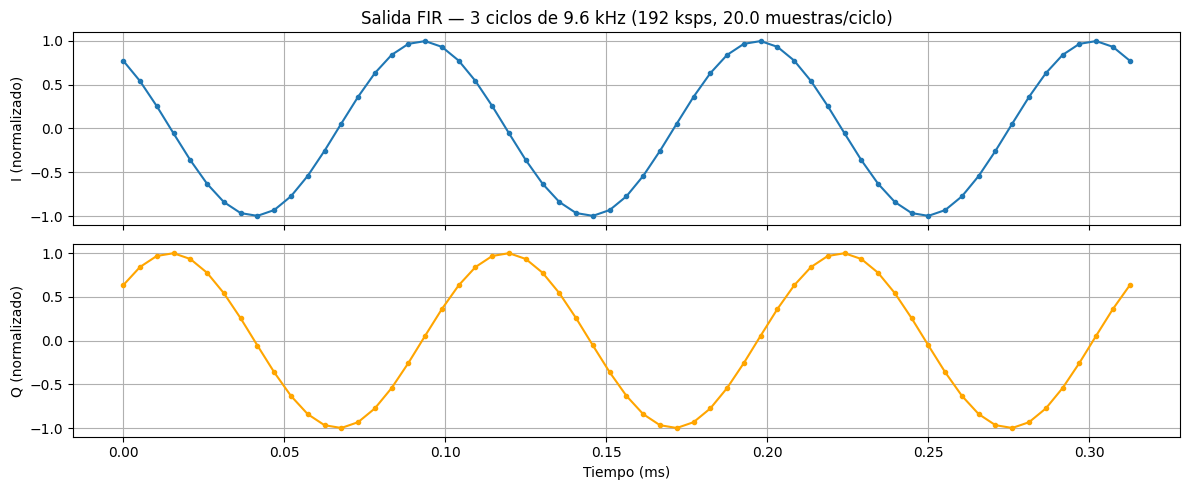

Pico en: 9.61 kHz (esperado: 9.6 kHz)


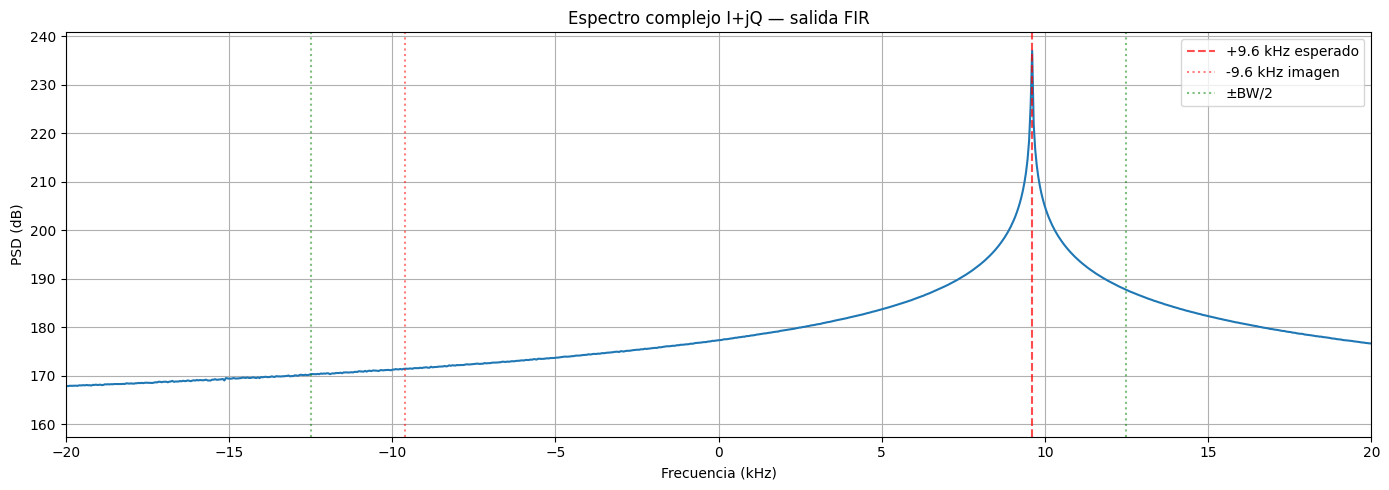

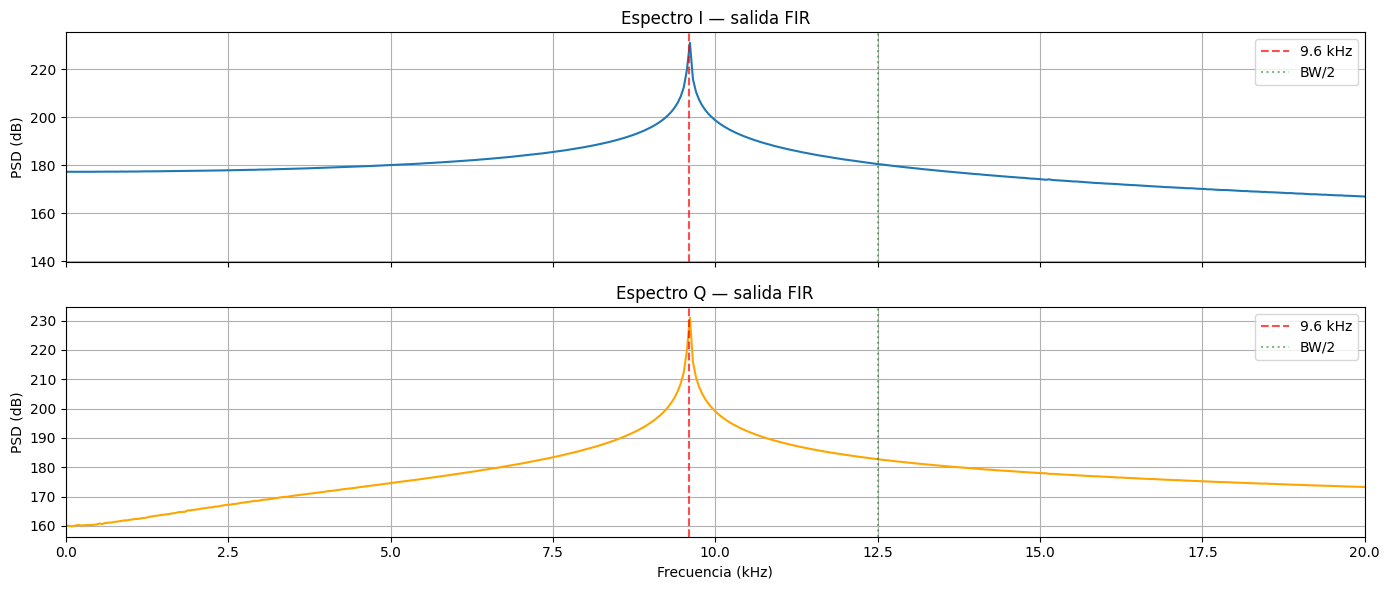

Listo.


In [6]:
# ============================================================
# CELDA 1 — Captura simple con LO fijo: tiempo y espectro
# ============================================================
# Usa la conexion ya abierta en la Celda 0. El LO ya quedo en f_lo_hz con
# el FIFO reseteado una vez -- alcanza con capturar directamente.

n_samples = 4096
I_bb, Q_bb = capturar_iq(sock, n_samples)

t = np.arange(n_samples) / fs_out * 1e3  # ms

# --- dominio temporal, 3 ciclos ---
n_ciclos = 3
t_max = n_ciclos / f_offset * 1e3
mask_t = t < t_max
muestras_por_ciclo = fs_out / f_offset

I_norm = I_bb / (np.max(np.abs(I_bb)) + 1e-10)
Q_norm = Q_bb / (np.max(np.abs(Q_bb)) + 1e-10)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t[mask_t], I_norm[mask_t], 'o-', markersize=3)
ax1.set_ylabel('I (normalizado)')
ax1.set_title(f'Salida FIR — {n_ciclos} ciclos de {f_offset/1e3:.1f} kHz '
              f'({fs_out/1e3:.0f} ksps, {muestras_por_ciclo:.1f} muestras/ciclo)')
ax1.grid(True)

ax2.plot(t[mask_t], Q_norm[mask_t], 'o-', markersize=3, color='orange')
ax2.set_ylabel('Q (normalizado)')
ax2.set_xlabel('Tiempo (ms)')
ax2.grid(True)
plt.tight_layout()
plt.show()

# --- espectro complejo bilateral ---
S     = np.fft.fftshift(np.fft.fft(I_bb + 1j * Q_bb))
freqs = np.fft.fftshift(np.fft.fftfreq(n_samples, d=1/fs_out))
Pxx   = 10 * np.log10(np.abs(S)**2 + 1e-20)

# buscar el pico SOLO dentro de una ventana alrededor de f_offset -- si se
# busca en todo el espectro (argmax sin restriccion), cualquier espurio o
# fuga fuera de esa zona puede ganarle al tono real y dar un resultado que
# no coincide con lo que se ve a simple vista en el grafico
ventana_hz = 5e3
mask_pico = np.abs(freqs - f_offset) <= ventana_hz
freq_peak = freqs[mask_pico][np.argmax(Pxx[mask_pico])]
print(f"Pico en: {freq_peak/1e3:.2f} kHz (esperado: {f_offset/1e3:.1f} kHz)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(freqs/1e3, Pxx)
ax.axvline( f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'+{f_offset/1e3:.1f} kHz esperado')
ax.axvline(-f_offset/1e3, color='r', linestyle=':', alpha=0.5,
            label=f'-{f_offset/1e3:.1f} kHz imagen')
ax.axvline( 12.5, color='g', linestyle=':', alpha=0.5, label='±BW/2')
ax.axvline(-12.5, color='g', linestyle=':', alpha=0.5)
ax.set_xlabel('Frecuencia (kHz)')
ax.set_ylabel('PSD (dB)')
ax.set_title('Espectro complejo I+jQ — salida FIR')
ax.set_xlim(f_min_khz, f_max_khz)
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

# --- espectro I y Q por separado ---
Pxx_I   = 10 * np.log10(np.abs(np.fft.rfft(I_bb))**2 + 1e-20)
Pxx_Q   = 10 * np.log10(np.abs(np.fft.rfft(Q_bb))**2 + 1e-20)
freqs_r = np.fft.rfftfreq(n_samples, d=1/fs_out)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax1.plot(freqs_r/1e3, Pxx_I)
ax1.axvline(f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'{f_offset/1e3:.1f} kHz')
ax1.axvline(12.5, color='g', linestyle=':', alpha=0.5, label='BW/2')
ax1.set_ylabel('PSD (dB)'); ax1.set_title('Espectro I — salida FIR')
ax1.set_xlim(0, f_max_khz); ax1.legend(); ax1.grid(True)

ax2.plot(freqs_r/1e3, Pxx_Q, color='orange')
ax2.axvline(f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'{f_offset/1e3:.1f} kHz')
ax2.axvline(12.5, color='g', linestyle=':', alpha=0.5, label='BW/2')
ax2.set_ylabel('PSD (dB)'); ax2.set_xlabel('Frecuencia (kHz)')
ax2.set_title('Espectro Q — salida FIR')
ax2.set_xlim(0, f_max_khz); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

print("Listo.")


Centro del barrido (LO)   : 10.7000 MHz
Tono TX fijo (autonomo)   : 10.709600 MHz (offset +9.6 kHz)
Ancho del barrido         : 180 kHz, paso 2.0 kHz

NOTA: el FIFO se resetea una sola vez, antes de arrancar el barrido
(no en cada punto), para que la fase medida sea comparable entre puntos.

Barriendo 91 puntos...
  Offset (kHz)    f_LO (MHz)   Potencia (dB)   Fase señal (deg)
         -90.0       10.6100            84.7             -59.92
         -88.0       10.6120            84.8            -161.34
         -86.0       10.6140            85.0             148.47
         -84.0       10.6160            84.9             140.19
         -82.0       10.6180            85.7              -6.82
         -80.0       10.6200            85.3            -123.58
         -78.0       10.6220            85.3            -107.05
         -76.0       10.6240            85.7              78.73
         -74.0       10.6260            86.0            -100.40
         -72.0       10.6280            85.4

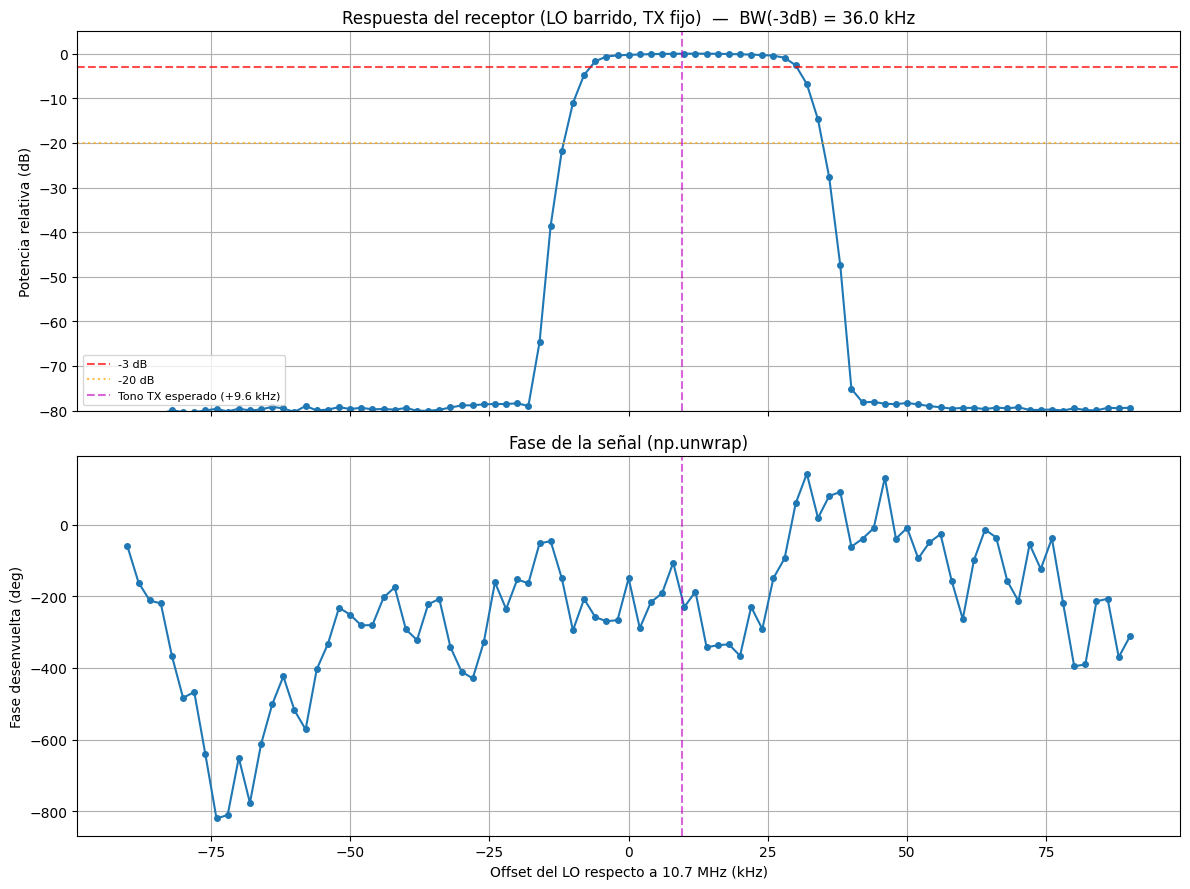

Conexion cerrada.
Listo.


In [7]:
# ============================================================
# CELDA 2 — Barrido de LO: potencia y fase en un solo recorrido
# ============================================================
# Cada punto del barrido ya captura el IQ completo, asi que potencia y
# fase se calculan de la MISMA captura -- no hace falta barrer dos veces.
#
# Metodo:
#   1. Barrer el PINC del LO (osc_0, RX) en un rango centrado en 10.7 MHz,
#      cambiando el PINC en caliente (sin resetear en cada punto -- el
#      reset se hace una sola vez, antes de arrancar el barrido)
#   2. En cada punto, medir potencia total y fase de la señal
#   3. Graficar potencia y fase (desenvuelta) vs offset del LO
#
# Como el tono TX esta fijo en 10.7 MHz + 9.6 kHz, el pico de potencia
# deberia aparecer en offset = +9.6 kHz respecto al centro del barrido.
#
# La fase real puede dar varias vueltas completas de 360 grados entre un
# punto y el siguiente (segun el retardo total de la cadena); se aplica
# np.unwrap() a la secuencia antes de graficar, y solo se muestra esa
# version desenvuelta (el valor crudo, entre -180 y +180, no aporta nada
# util por si solo).

SWEEP_BW   = 180e3
SWEEP_STEP = 2e3
N_SAMPLES  = 4096

f_lo_centro = f_lo_hz

offsets = np.arange(-SWEEP_BW/2, SWEEP_BW/2 + SWEEP_STEP, SWEEP_STEP)
potencias = []
fases_senal = []

print(f"Centro del barrido (LO)   : {f_lo_centro/1e6:.4f} MHz")
print(f"Tono TX fijo (autonomo)   : {f_tono_tx/1e6:.6f} MHz (offset +{(f_tono_tx-f_lo_centro)/1e3:.1f} kHz)")
print(f"Ancho del barrido         : {SWEEP_BW/1e3:.0f} kHz, paso {SWEEP_STEP/1e3:.1f} kHz")
print()
print("NOTA: el FIFO se resetea una sola vez, antes de arrancar el barrido")
print("(no en cada punto), para que la fase medida sea comparable entre puntos.")

# reset UNICO antes de arrancar el barrido
set_lo(sock, f_lo_centro + offsets[0], con_reset=True)
resetear_fifo(sock)
time.sleep(0.05)

print(f"\nBarriendo {len(offsets)} puntos...")
print(f"{'Offset (kHz)':>14}  {'f_LO (MHz)':>12}  {'Potencia (dB)':>14}  {'Fase señal (deg)':>17}")

for offset in offsets:
    f_lo = f_lo_centro + offset
    set_lo(sock, f_lo)   # en caliente, sin resetear
    time.sleep(0.03)

    I, Q = capturar_iq(sock, N_SAMPLES)
    iq = I + 1j * Q
    pwr = medir_potencia(iq)

    f_bb_esperada = f_tono_tx - f_lo
    fase_sig, f_pico = medir_fase_senal(iq, f_bb_esperada, fs_out)

    potencias.append(pwr)
    fases_senal.append(fase_sig)

    print(f"{offset/1e3:>14.1f}  {f_lo/1e6:>12.4f}  {pwr:>14.1f}  {fase_sig:>17.2f}")

# restaurar LO al centro
set_lo(sock, f_lo_centro)

potencias   = np.array(potencias)
fases_senal = np.array(fases_senal)
fases_unwrap = np.rad2deg(np.unwrap(np.deg2rad(fases_senal)))
offsets_khz = offsets / 1e3

pmax = potencias.max()
potencias_norm = potencias - pmax

mask_3db = potencias_norm >= -3.0
if mask_3db.any():
    bw_3db = (offsets[mask_3db].max() - offsets[mask_3db].min()) / 1e3
    print(f"\nAncho de banda a -3 dB: {bw_3db:.1f} kHz")
else:
    bw_3db = None
    print("\nNo se pudo determinar el BW a -3 dB")

# ============================================================
# GRAFICAS
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

ax1.plot(offsets_khz, potencias_norm, 'o-', markersize=4)
ax1.axhline(-3,  color='r', ls='--', alpha=0.7, label='-3 dB')
ax1.axhline(-20, color='orange', ls=':', alpha=0.7, label='-20 dB')
ax1.axvline((f_tono_tx - f_lo_centro)/1e3, color='m', ls='--', alpha=0.6,
            label=f'Tono TX esperado (+{(f_tono_tx-f_lo_centro)/1e3:.1f} kHz)')
ax1.set_ylabel('Potencia relativa (dB)')
ax1.set_ylim(-80, 5)
if bw_3db:
    ax1.set_title(f'Respuesta del receptor (LO barrido, TX fijo)  —  BW(-3dB) = {bw_3db:.1f} kHz')
else:
    ax1.set_title('Respuesta del receptor (LO barrido, TX fijo)')
ax1.legend(fontsize=8); ax1.grid(True)

ax2.plot(offsets_khz, fases_unwrap, 'o-', markersize=4, color='tab:blue')
ax2.axvline((f_tono_tx - f_lo_centro)/1e3, color='m', ls='--', alpha=0.6)
ax2.set_ylabel('Fase desenvuelta (deg)')
ax2.set_xlabel('Offset del LO respecto a 10.7 MHz (kHz)')
ax2.set_title('Fase de la señal (np.unwrap)')
ax2.grid(True)

plt.tight_layout()
plt.savefig('sweep_lo_tx_fijo.png', dpi=110)
print("\nGrafica -> sweep_lo_tx_fijo.png")
plt.show()

# --- cierre de la conexion (unica del notebook) ---
sock.close()
print("Conexion cerrada.")
print("Listo.")
